# Download meteoscreening variables

**notebook version**: `3` (4 Jul 2024)  
**new in this version**: added check if downloaded data is indeed in 30MIN time resolution

- This notebook can be used to download data from the database `InfluxDB`
- Data are stored to a `.csv` file in this folder

</br>

# Info about data sources

- `SW_IN`: NABEL (2004-2018), mst (2005-2021), diive (2022-2025)
- ETH data are the main data
- NABEL data are used to gap-fill ETH data to create a complete time series 2004-2025
- Gap-filling is done using XGBoost, it also uses e.g. timestamp and potential radiation as features

Legend:
- NABEL ... Data from [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), meteoscreening with [diive](https://github.com/holukas/diive)
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive

</br>

# ⚙️Settings

## Data settings

In [1]:
DIRCONF = r'F:\Sync\luhk_work\20 - CODING\22 - POET\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files: needed e.g. for connection to database
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'  # 30MIN time resolution
SITE_LAT = 47.478333   # CH-LAE
SITE_LON = 8.364389  # CH-LAE

## Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme('notebook')
from diive.core.plotting.timeseries import TimeSeries
from dbc_influxdb import dbcInflux
import diive as dv
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.core.times.times import DetectFrequency
from diive.core.times.times import TimestampSanitizer
from diive.core.io.files import save_parquet
from diive.pkgs.createvar.potentialradiation import potrad
from diive.pkgs.corrections.offsetcorrection import remove_relativehumidity_offset, remove_radiation_zero_offset
from diive.pkgs.gapfilling.xgboost_ts import XGBoostTS
import warnings
from influxdb_client.client.warnings import MissingPivotFunction
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")
version_dbc = importlib.metadata.version("dbc_influxdb")
print(f"dbc-influxdb version: v{version_dbc}")
dbc = dbcInflux(dirconf=DIRCONF)  # Connect to database

diive version: v0.90.0
dbc-influxdb version: v0.13.1
Reading configuration files was successful.
Connection to database works.


</br>

</br>

# ⬇️ `NABEL` data (2004-2018) and ETH data (2022-2025) from `diive` meteoscreening

## Download

In [3]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['SW_IN_NABEL_T1_49_1', 'SW_IN_T1_47_1']
MEASUREMENTS = ['SW']
START = '2006-01-01 00:00:01'
STOP = '2007-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_diive'

nabel_eth_diive_swin_2004_2018_2022_2025, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)


DOWNLOADING
    from bucket ch-lae_processed
    variables ['SW_IN_NABEL_T1_49_1', 'SW_IN_T1_47_1']
    from measurements ['SW']
    from data version ['meteoscreening_diive']
    between 2006-01-01 00:00:01 and 2007-01-01 00:00:01
    with timezone offset to UTC of 1
Using querystring:
from(bucket: "ch-lae_processed") |> range(start: 2006-01-01T00:00:01+01:00, stop: 2007-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "SW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_diive") |> filter(fn: (r) => r["_field"] == "SW_IN_NABEL_T1_49_1" or r["_field"] == "SW_IN_T1_47_1") |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
Used querystring: from(bucket: "ch-lae_processed") |> range(start: 2006-01-01T00:00:01+01:00, stop: 2007-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "SW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_diive") |> filter(fn: (r) => r["_field"] == "SW_IN_NABEL_T1_49_1" or r["_field"] == "SW_I

In [4]:
nabel_eth_diive_swin_2004_2018_2022_2025

,SW_IN_NABEL_T1_49_1
TIMESTAMP_END,
2006-01-01 00:30:00,0.0
2006-01-01 01:00:00,0.0
2006-01-01 01:30:00,0.0
2006-01-01 02:00:00,0.0
2006-01-01 02:30:00,0.0
...,...
2006-12-31 22:00:00,0.0
2006-12-31 22:30:00,0.0
2006-12-31 23:00:00,0.0


## Sanitize timestamp

In [5]:
nabel_eth_diive_swin_2004_2018_2022_2025 = TimestampSanitizer(data=nabel_eth_diive_swin_2004_2018_2022_2025, output_middle_timestamp=True).get()
nabel_eth_diive_swin_2004_2018_2022_2025

,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,
2006-01-01 00:15:00,0.0
2006-01-01 00:45:00,0.0
2006-01-01 01:15:00,0.0
2006-01-01 01:45:00,0.0
2006-01-01 02:15:00,0.0
...,...
2006-12-31 21:45:00,0.0
2006-12-31 22:15:00,0.0
2006-12-31 22:45:00,0.0


## Dataframe

In [6]:
print(nabel_eth_diive_swin_2004_2018_2022_2025)

                     SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE                        
2006-01-01 00:15:00                  0.0
2006-01-01 00:45:00                  0.0
2006-01-01 01:15:00                  0.0
2006-01-01 01:45:00                  0.0
2006-01-01 02:15:00                  0.0
...                                  ...
2006-12-31 21:45:00                  0.0
2006-12-31 22:15:00                  0.0
2006-12-31 22:45:00                  0.0
2006-12-31 23:15:00                  0.0
2006-12-31 23:45:00                  0.0

[17520 rows x 1 columns]


</br>

# ⬇️ Data from `mst` meteoscreening (2004-2021)

## Download

In [7]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['SW_IN_T1_47_1']
MEASUREMENTS = ['SW']
START = '2006-01-01 00:00:01'
STOP = '2007-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_mst'

mst_swin_2004_2021, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)


DOWNLOADING
    from bucket ch-lae_processed
    variables ['SW_IN_T1_47_1']
    from measurements ['SW']
    from data version ['meteoscreening_mst']
    between 2006-01-01 00:00:01 and 2007-01-01 00:00:01
    with timezone offset to UTC of 1
Using querystring:
from(bucket: "ch-lae_processed") |> range(start: 2006-01-01T00:00:01+01:00, stop: 2007-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "SW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_mst") |> filter(fn: (r) => r["_field"] == "SW_IN_T1_47_1") |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
Used querystring: from(bucket: "ch-lae_processed") |> range(start: 2006-01-01T00:00:01+01:00, stop: 2007-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "SW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_mst") |> filter(fn: (r) => r["_field"] == "SW_IN_T1_47_1") |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
querystring was construc

In [8]:
mst_swin_2004_2021

,SW_IN_T1_47_1
TIMESTAMP_END,
2006-01-01 00:30:00,-4.361716
2006-01-01 01:00:00,-4.532968
2006-01-01 01:30:00,-4.711728
2006-01-01 02:00:00,-4.895925
2006-01-01 02:30:00,-4.909561
...,...
2006-12-31 22:00:00,-5.109272
2006-12-31 22:30:00,95.853203
2006-12-31 23:00:00,-9.243214


## Sanitize timestamp

In [9]:
mst_swin_2004_2021 = TimestampSanitizer(data=mst_swin_2004_2021, output_middle_timestamp=True).get()
mst_swin_2004_2021

,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,
2006-01-01 00:15:00,-4.361716
2006-01-01 00:45:00,-4.532968
2006-01-01 01:15:00,-4.711728
2006-01-01 01:45:00,-4.895925
2006-01-01 02:15:00,-4.909561
...,...
2006-12-31 21:45:00,-5.109272
2006-12-31 22:15:00,95.853203
2006-12-31 22:45:00,-9.243214


## Dataframe

In [10]:
print(mst_swin_2004_2021)

                     SW_IN_T1_47_1
TIMESTAMP_MIDDLE                  
2006-01-01 00:15:00      -4.361716
2006-01-01 00:45:00      -4.532968
2006-01-01 01:15:00      -4.711728
2006-01-01 01:45:00      -4.895925
2006-01-01 02:15:00      -4.909561
...                            ...
2006-12-31 21:45:00      -5.109272
2006-12-31 22:15:00      95.853203
2006-12-31 22:45:00      -9.243214
2006-12-31 23:15:00      -8.896067
2006-12-31 23:45:00      -7.205295

[17520 rows x 1 columns]


</br>

# ❇️ Merge data

In [11]:
# Merge data on index
# TODO swin_2004_2025 = nabel_eth_diive_swin_2004_2018_2022_2025.copy()
# TODO swin_2004_2025['SW_IN_T1_47_1'] = swin_2004_2025['SW_IN_T1_47_1'].combine_first(mst_swin_2004_2021['SW_IN_T1_47_1'])
swin_2004_2025 = pd.concat([nabel_eth_diive_swin_2004_2018_2022_2025, mst_swin_2004_2021], axis=1)
swin_2004_2025

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,,
2006-01-01 00:15:00,0.0,-4.361716
2006-01-01 00:45:00,0.0,-4.532968
2006-01-01 01:15:00,0.0,-4.711728
2006-01-01 01:45:00,0.0,-4.895925
2006-01-01 02:15:00,0.0,-4.909561
...,...,...
2006-12-31 21:45:00,0.0,-5.109272
2006-12-31 22:15:00,0.0,95.853203
2006-12-31 22:45:00,0.0,-9.243214


## Heatmap

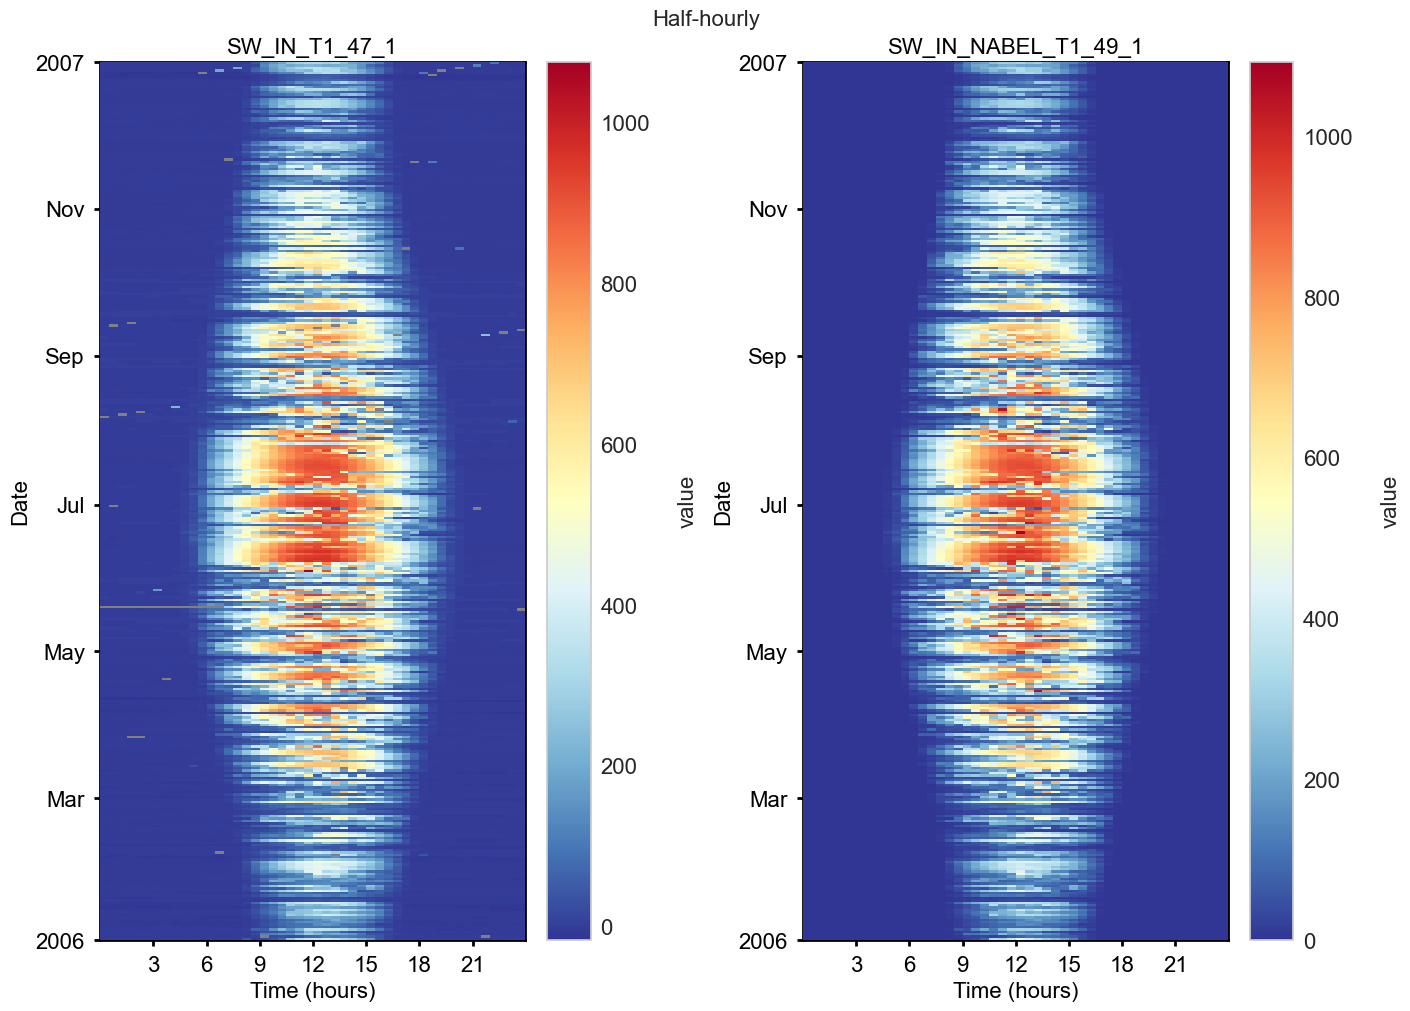

In [12]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.heatmapdatetime(series=swin_2004_2025['SW_IN_T1_47_1'], title="SW_IN_T1_47_1", ax=axs[0], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=swin_2004_2025['SW_IN_NABEL_T1_49_1'], title="SW_IN_NABEL_T1_49_1", ax=axs[1], cb_digits_after_comma=0, zlabel="value").plot()

</br>

## Sanitize timestamp

In [13]:
swin_2004_2025 = TimestampSanitizer(data=swin_2004_2025, output_middle_timestamp=True).get()
swin_2004_2025

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,,
2006-01-01 00:15:00,0.0,-4.361716
2006-01-01 00:45:00,0.0,-4.532968
2006-01-01 01:15:00,0.0,-4.711728
2006-01-01 01:45:00,0.0,-4.895925
2006-01-01 02:15:00,0.0,-4.909561
...,...,...
2006-12-31 21:45:00,0.0,-5.109272
2006-12-31 22:15:00,0.0,95.853203
2006-12-31 22:45:00,0.0,-9.243214


## Heatmap

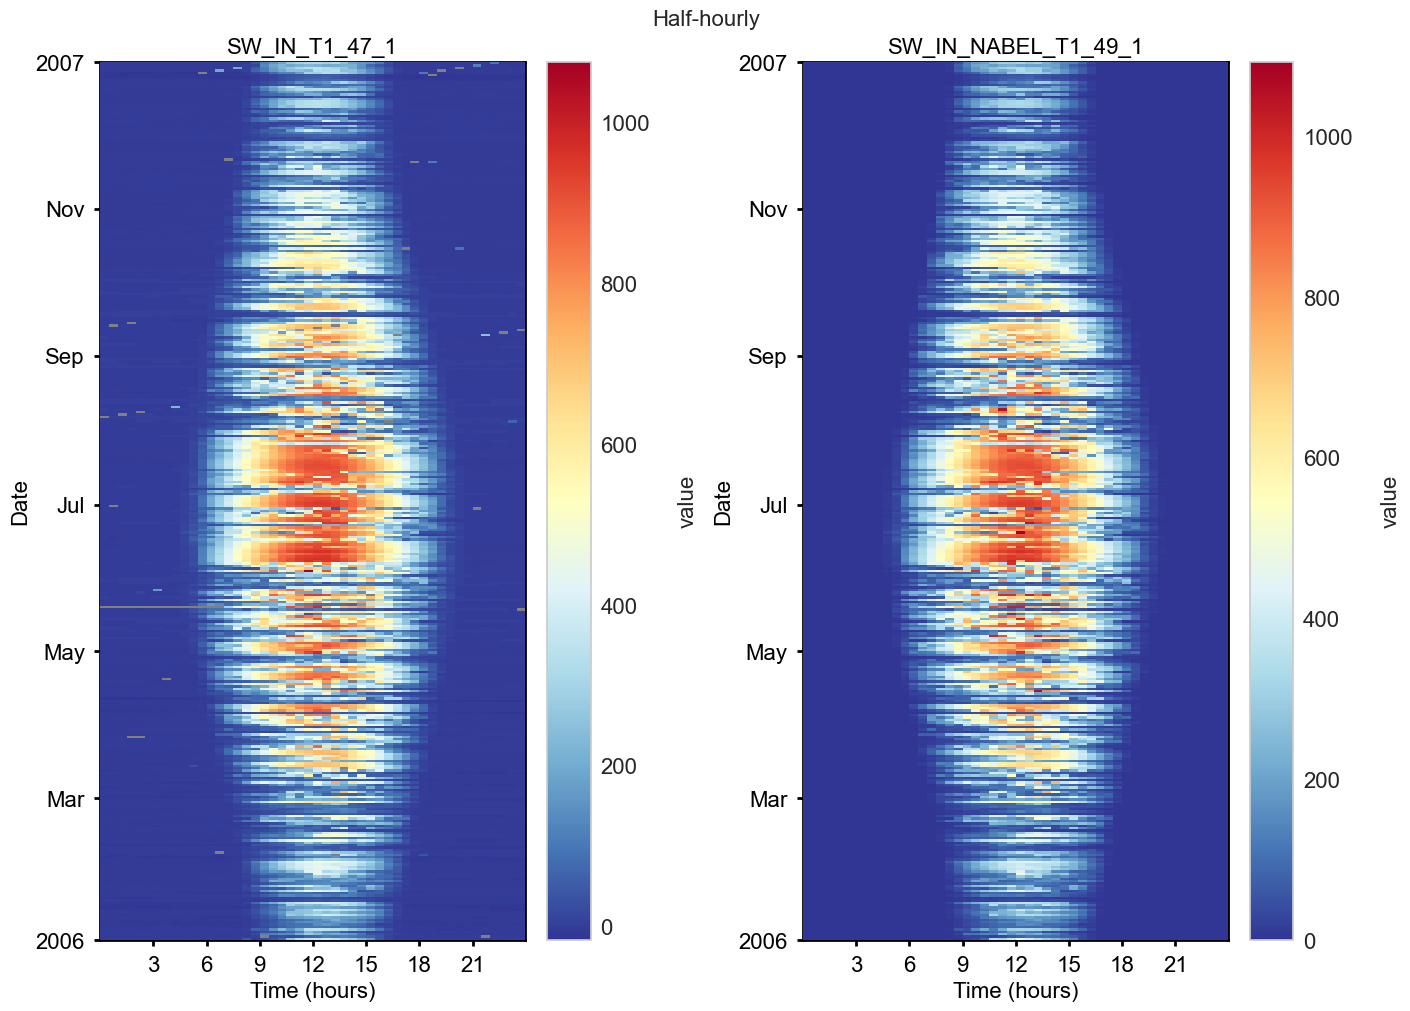

In [14]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.heatmapdatetime(series=swin_2004_2025['SW_IN_T1_47_1'], title="SW_IN_T1_47_1", ax=axs[0], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=swin_2004_2025['SW_IN_NABEL_T1_49_1'], title="SW_IN_NABEL_T1_49_1", ax=axs[1], cb_digits_after_comma=0, zlabel="value").plot()

</br>

# ✴️ Corrections

### Timestamp shift in August 2012
**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

In [15]:
# AFFECTED_VARS = ['SW_IN_T1_47_1']
# _df = swin_2004_2025.copy()

# for av in AFFECTED_VARS:
#     fig = plt.figure(figsize=(24, 6), dpi=72)
#     fig.suptitle(f"{av}")
#     gs = gridspec.GridSpec(1, 5)  # rows, cols
#     gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
#     ax_before = fig.add_subplot(gs[0, 0])
#     ax_unshifted = fig.add_subplot(gs[0, 1])
#     ax_shifted = fig.add_subplot(gs[0, 2])
#     ax_after = fig.add_subplot(gs[0, 3])
#     ax_corrected = fig.add_subplot(gs[0, 4])
    
#     # Show time period around issue, before correction
#     # _series = _df[av].copy()
#     _show_locs = (_df.index >= '2012-08-01 00:00') & (_df.index <= '2012-09-01 00:00')
#     dv.heatmapdatetime(series=_df.loc[_show_locs, av], ax=ax_before, title="Before correction").plot()
    
#     # Get shifted time period
#     _series_corrected = _df.loc[_show_locs, av].copy()
#     # Identify shifted time period
#     ISSUE_START = '2012-08-09 00:00'
#     ISSUE_END = '2012-08-17 00:00'
#     _shifted_locs = (_df.index >= ISSUE_START) & (_df.index <= ISSUE_END)
#     _series_shifted = _df.loc[_shifted_locs, av].copy()
#     _series_shifted = _series_shifted.dropna()
#     dv.heatmapdatetime(series=_series_shifted, ax=ax_unshifted, title="UNSHIFTED time period").plot()
    
#     # Shift SW_IN by 15.5 hours during shifted time period, create corrected time series
#     _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=15.5)
#     dv.heatmapdatetime(series=_series_shifted, ax=ax_shifted, title="SHIFTED time period").plot()
    
#     # Delete data between start of issue and the last timestamp of shifted data
#     _overwrite_locs = (_df.index >= ISSUE_START) & (_df.index <= _series_shifted.index[-1])
#     _df.loc[_overwrite_locs, av] = np.nan
#     dv.heatmapdatetime(series=_df.loc[_show_locs, av], ax=ax_after, title="After deletion").plot()
    
#     # Fill in corrected values
#     _df.loc[_overwrite_locs, av] = _series_shifted
#     # _series_corrected = _series_corrected.combine_first(_series_shifted)
#     dv.heatmapdatetime(series=_df.loc[_show_locs, av], ax=ax_corrected, title="After correction").plot()
    
#     # print(_series_shifted.index[-1])
#     # print(_series_shifted)
#     # print(_series_corrected[_overwrite_locs])

In [16]:
# swin_2004_2025 = _df.copy()
# swin_2004_2025

## Remove zero offset < 0 from `SW_IN`

[remove_radiation_zero_offset]  running remove_radiation_zero_offset ...
[remove_radiation_zero_offset]  running remove_radiation_zero_offset ...


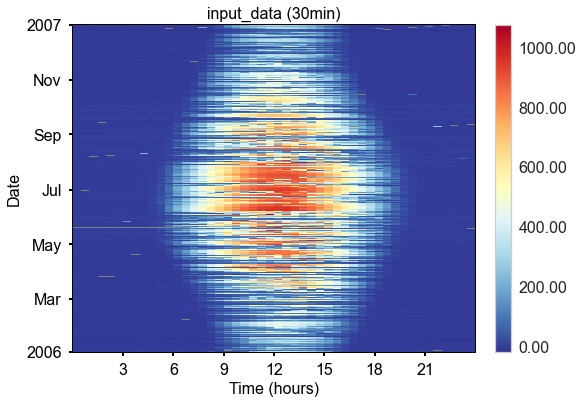

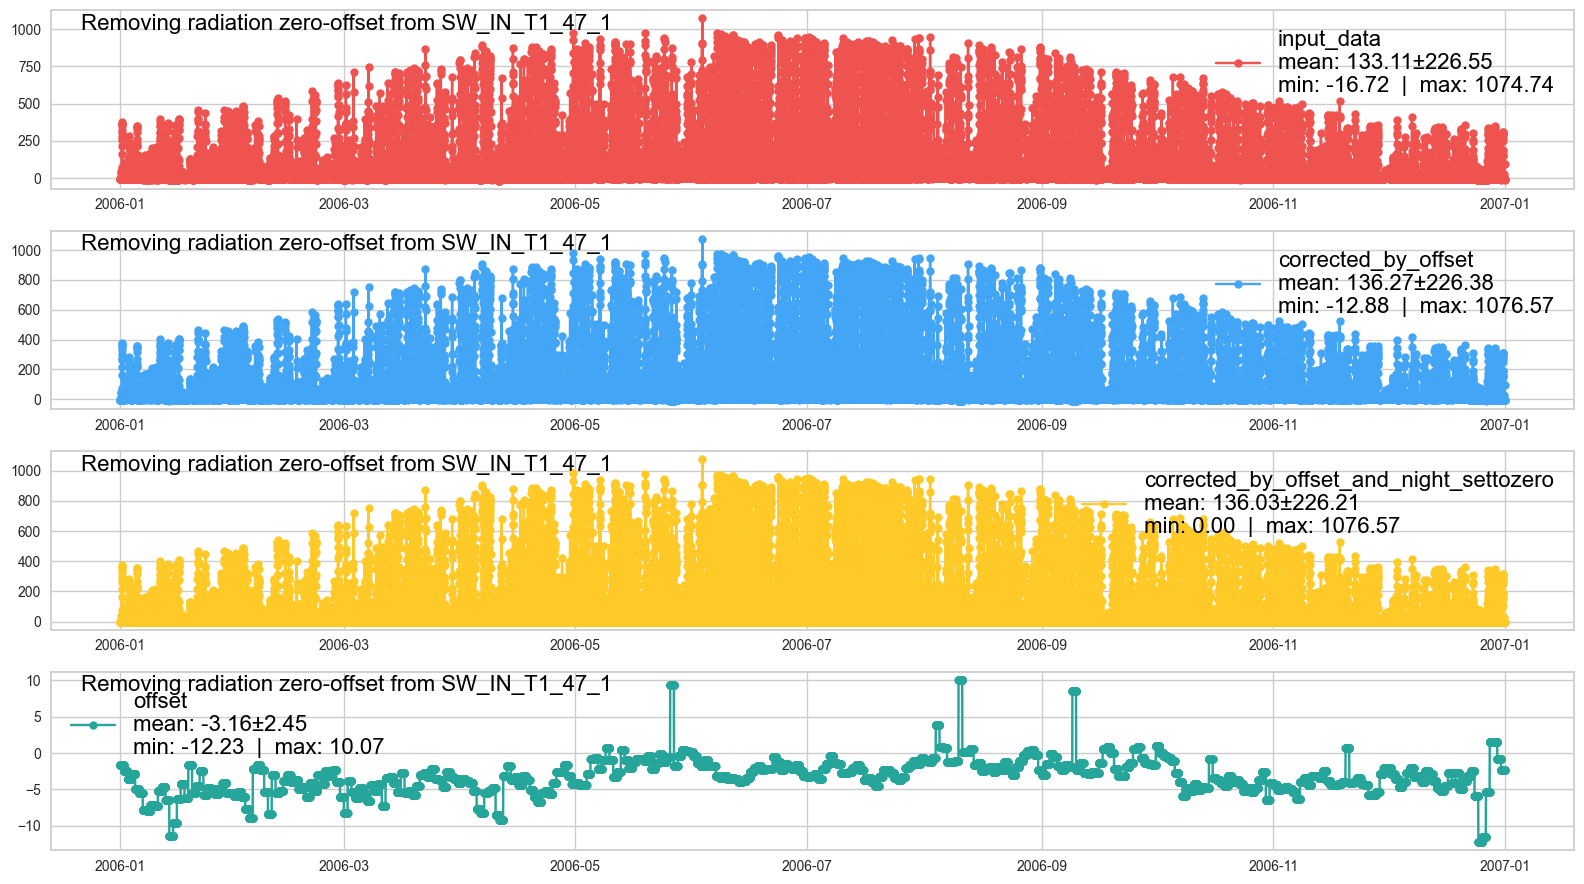

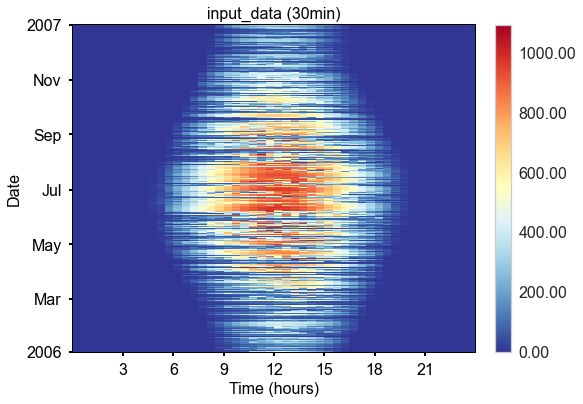

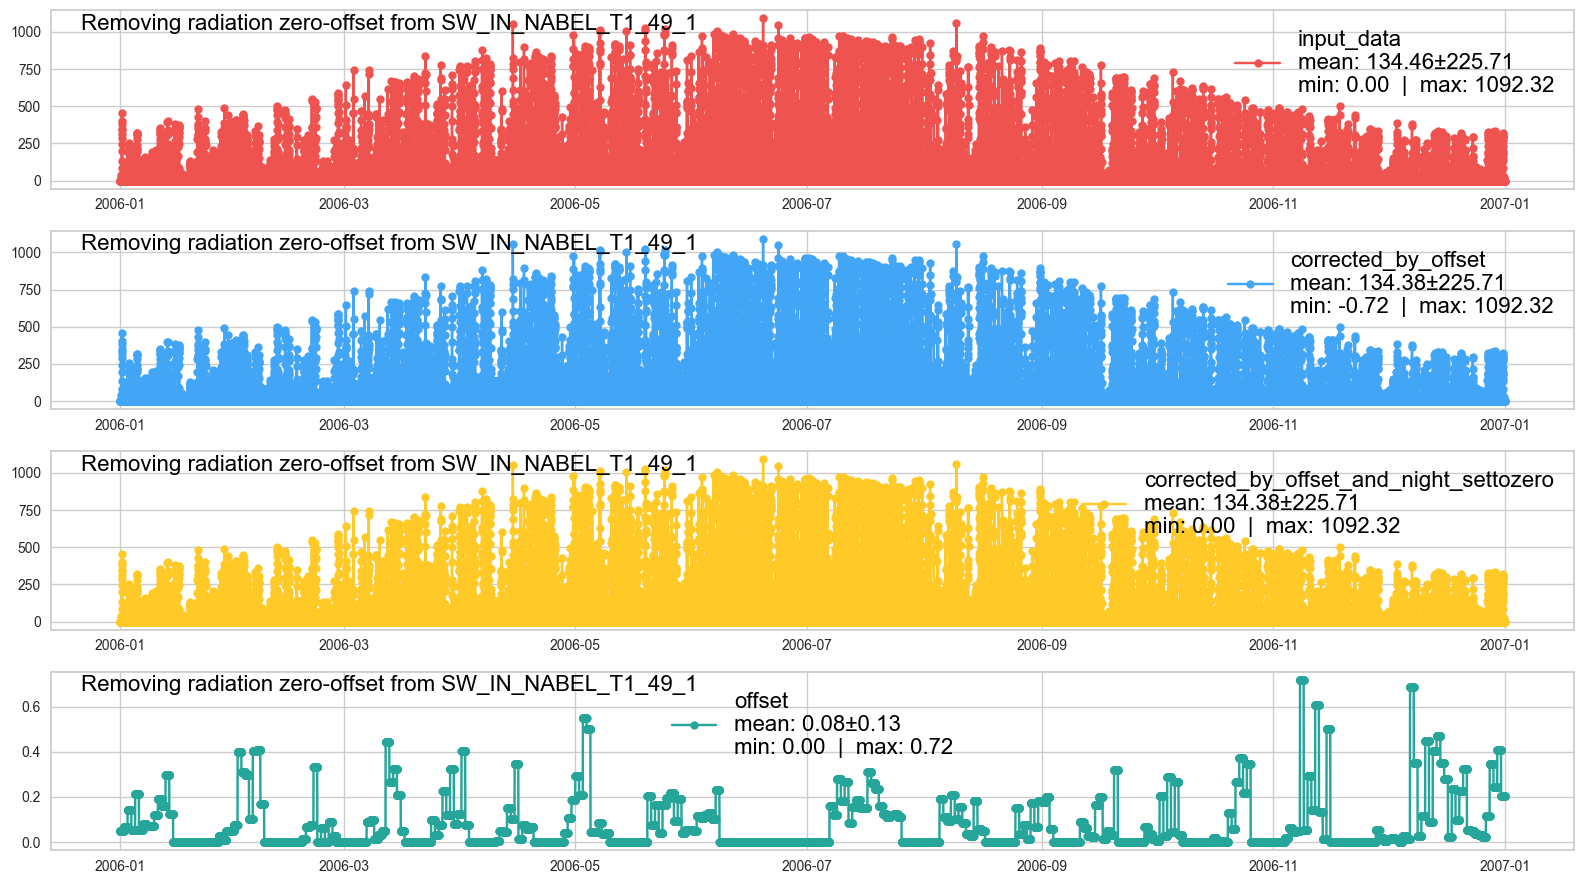

In [17]:
_swin = swin_2004_2025['SW_IN_T1_47_1'].copy()
_swin_corrected = remove_radiation_zero_offset(series=_swin, lat=SITE_LAT, lon=SITE_LON, utc_offset=1, showplot=True)
swin_2004_2025['SW_IN_T1_47_1'] = np.nan
swin_2004_2025['SW_IN_T1_47_1'] = _swin_corrected

_swin = swin_2004_2025['SW_IN_NABEL_T1_49_1'].copy()
_swin_corrected = remove_radiation_zero_offset(series=_swin, lat=SITE_LAT, lon=SITE_LON, utc_offset=1, showplot=True)
swin_2004_2025['SW_IN_NABEL_T1_49_1'] = np.nan
swin_2004_2025['SW_IN_NABEL_T1_49_1'] = _swin_corrected

</br>

</br>

</br>

# 🟥 Gap-filling NABEL (2004-2018)

## Target and features

In [18]:
TARGET = "SW_IN_NABEL_T1_49_1"
subset = pd.DataFrame()
subset = swin_2004_2025[['SW_IN_NABEL_T1_49_1']].copy()
subset = subset.loc[subset.index.year <= 2018].copy()
subset['SW_IN_POT'] = potrad(timestamp_index=subset.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
subset

,SW_IN_NABEL_T1_49_1,SW_IN_POT
TIMESTAMP_MIDDLE,,
2006-01-01 00:15:00,0.0,0.0
2006-01-01 00:45:00,0.0,0.0
2006-01-01 01:15:00,0.0,0.0
2006-01-01 01:45:00,0.0,0.0
2006-01-01 02:15:00,0.0,0.0
...,...,...
2006-12-31 21:45:00,0.0,0.0
2006-12-31 22:15:00,0.0,0.0
2006-12-31 22:45:00,0.0,0.0


In [19]:
subset = subset.loc[subset['SW_IN_POT'] > 0, :].copy()
subset

,SW_IN_NABEL_T1_49_1,SW_IN_POT
TIMESTAMP_MIDDLE,,
2006-01-01 08:45:00,3.891345,87.881303
2006-01-01 09:15:00,21.516078,174.686134
2006-01-01 09:45:00,37.416678,251.779510
2006-01-01 10:15:00,82.053278,317.842341
2006-01-01 10:45:00,339.336211,371.744274
...,...,...
2006-12-31 14:15:00,183.630393,358.576027
2006-12-31 14:45:00,149.090726,301.817806
2006-12-31 15:15:00,132.652093,233.149089


## Initialize gap-filling

In [20]:
xgbts = XGBoostTS(
    input_df=subset,
    target_col=TARGET,
    verbose=1,
    features_lag=None,
    features_lag_exclude_cols=None,
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=False,
    perm_n_repeats=1,
    n_estimators=3000,    
    random_state=42,
    # booster='gbtree',  # gbtree (default), gblinear, dart
    # device='cpu',
    # validate_parameters=True,
    # disable_default_eval_metric=False,
    early_stopping_rounds=100,
    # learning_rate=0.1,
    # max_depth=9,
    # max_delta_step=0,
    # subsample=1,
    # min_split_loss=0,
    # min_child_weight=1,
    # colsample_bytree=1,
    # colsample_bylevel=1,
    # colsample_bynode=1,
    # reg_lambda=1,
    # reg_alpha=0,
    # tree_method='auto',  # auto, hist, approx, exact
    # scale_pos_weight=1,
    # grow_policy='depthwise',  # depthwise, lossguide
    # max_leaves=0,
    # max_bin=256,
    # num_parallel_tree=1,
    n_jobs=-1
)



Starting gap-filling for
SW_IN_NABEL_T1_49_1
using <class 'xgboost.sklearn.XGBRegressor'>

Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 8760.


## Reduce features across years

In [21]:
xgbts.reduce_features()
xgbts.report_feature_reduction()


[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[0]	validation_0-rmse:209.59480	validation_1-rmse:209.59480
[1]	validation_0-rmse:180.19740	validation_1-rmse:180.19740
[2]	validation_0-rmse:161.85601	validation_1-rmse:161.85601
[3]	validation_0-rmse:150.76424	validation_1-rmse:150.76424
[4]	validation_0-rmse:143.25869	validation_1-rmse:143.25869
[5]	validation_0-rmse:137.07940	validation_1-rmse:137.07940
[6]	validation_0-rmse:133.03447	validation_1-rmse:133.03447
[7]	validation_0-rmse:130.38538	validation_1-rmse:130.38538
[8]	validation_0-rmse:127.78124	validation_1-rmse:127.78124
[9]	validation_0-rmse:124.95052	validation_1-rmse:124.95052
[10]	validation_0-rmse:122.71112	validation_1-rmse:122.71112
[11]	validation_0-rmse:119.58277	validation_1-rmse:119.58277
[12]	validation_0-rmse:118.12080	validation_1-rmse:118.12080
[13]	validation_0-rmse:116.05053	validation_1-rmse:116.05053
[14]	validation_0-rmse:114.41809	validation_1-rmse:114.41809
[15]	validation_0-

## Train model


Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2006-01-01 09:15:00 and 2006-12-31 16:15:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:209.53611	validation_1-rmse:212.59810
[1]	validation_0-rmse:181.00080	validation_1-rmse:184.66547
[2]	validation_0-rmse:163.06061	validation_1-rmse:168.59208
[3]	validation_0-rmse:151.85889	validation_1-rmse:158.17008
[4]	validation_0-rmse:144.85673	validation_1-rmse:152.52916
[5]	validation_0-rmse:138.99638	validation_1-rmse:146.97222
[6]	validation_0-rmse:134.58229	validation_1-rmse:142.81517
[7]	validation_0-rmse:131.77201	validation_1-rmse:140.65223
[8]	validation_0-rmse:128.25744	validation_1-rmse:137.99301
[9]	validation_0-rmse:126.28128	validation_1-rmse:136.94675
[10]	validation_0-rmse:123.24928	validation_1-rmse:134.33284
[11]	validation_0-rmse:120.87612	validation_1-rmse:131.99097
[12]	validation_0-rmse:119.18461	validation_1-rmse:130.67905
[13]	validation_0-rmse:1

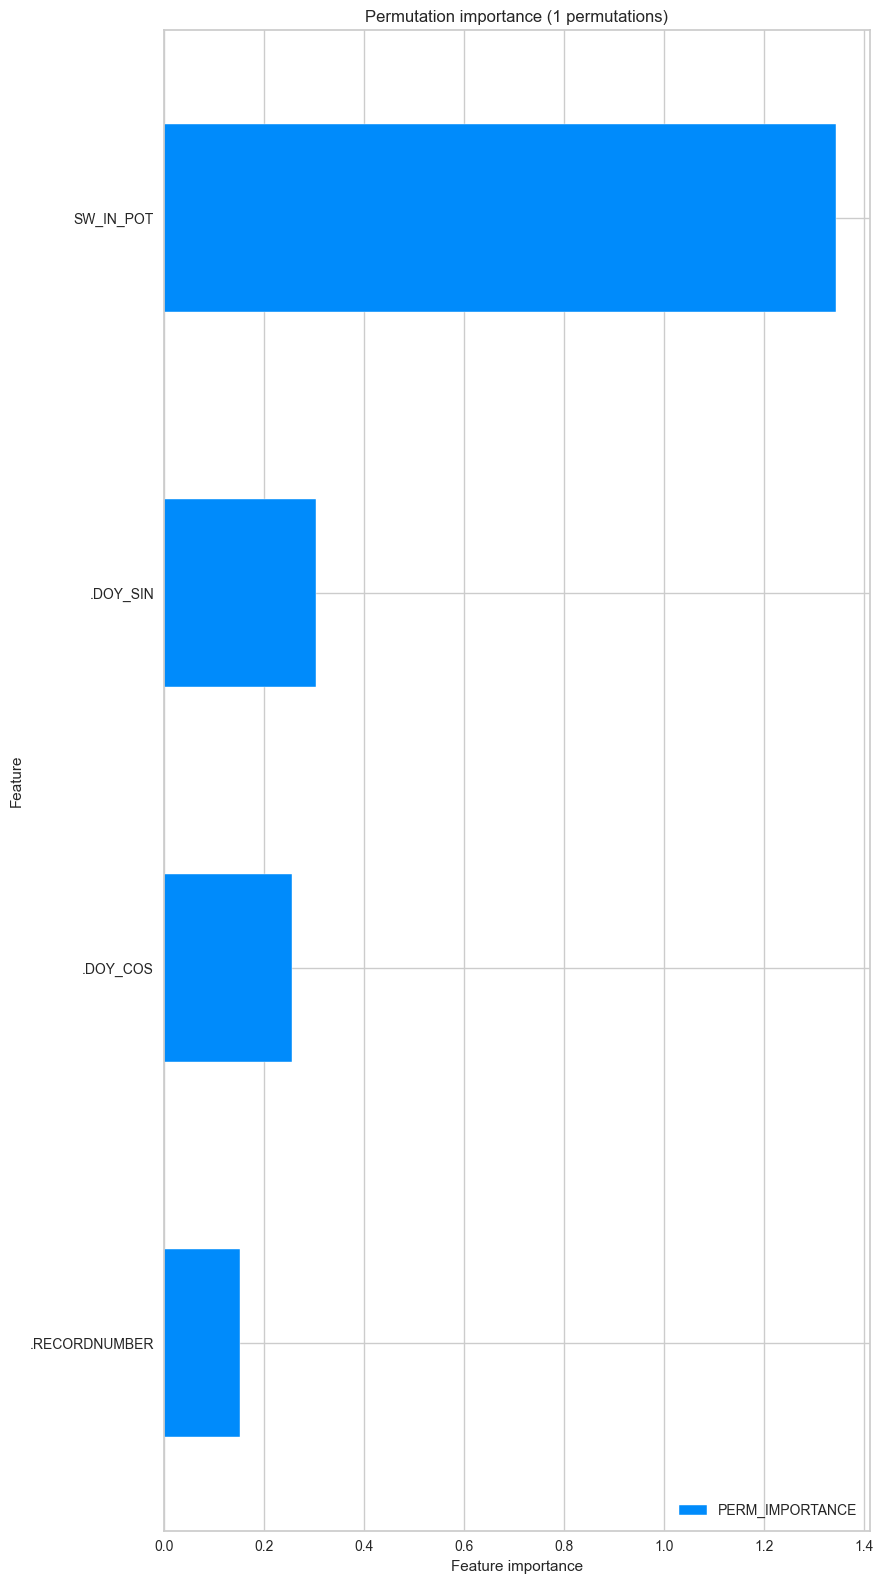

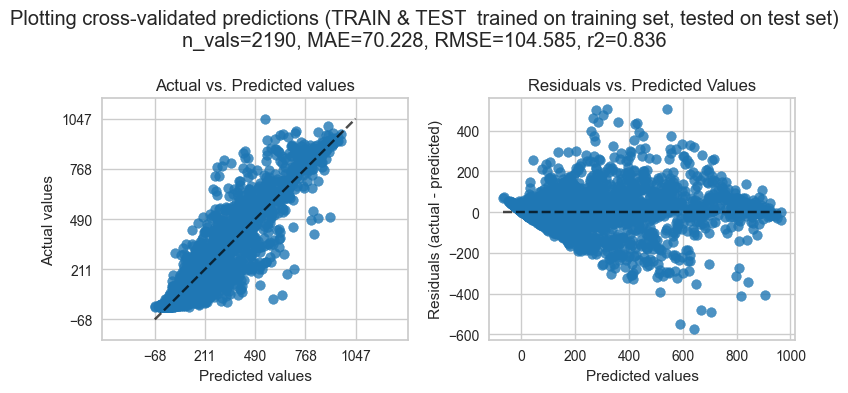

>>> Plotting residuals and prediction error ...


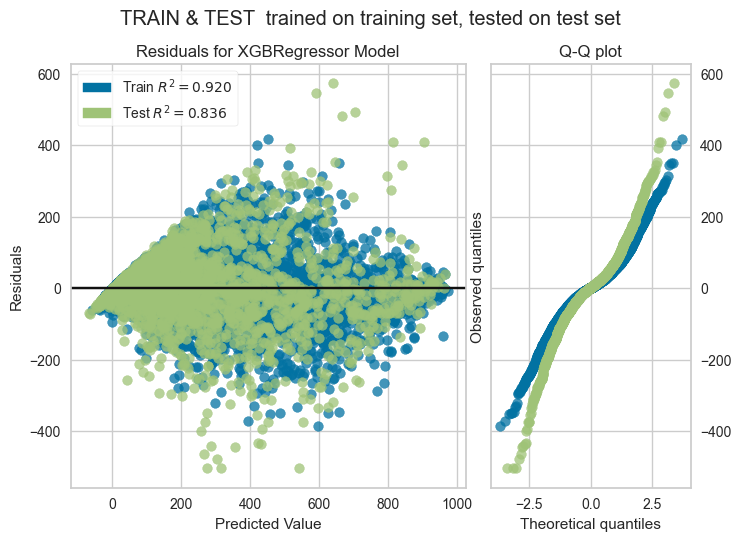

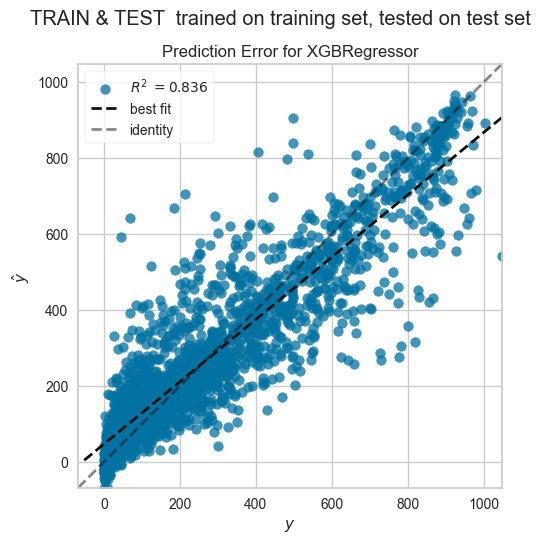

>>> Collecting results, details about training and testing can be accessed by calling .report_traintest().
>>> Done.

MODEL TRAINING & TESTING RESULTS

## DATA
  > target: SW_IN_NABEL_T1_49_1
  > features: 4 ['SW_IN_POT', '.DOY_SIN', '.DOY_COS', '.RECORDNUMBER']
  > 8760 records (with missing)
  > 8760 available records for target and all features (no missing values)
  > training on 6570 records (75.0%) of 6570 features between 2006-01-01 09:15:00 and 2006-12-31 16:15:00
  > testing on 2190 unseen records (25.0%) of SW_IN_NABEL_T1_49_1 between 2006-01-01 08:45:00 and 2006-12-31 15:45:00

## MODEL
  > the model was trained on training data (6570 records)
  > the model was tested on test data (2190 values)
  > estimator:  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=100,
             enable_categorical=False, eval_metric=None, feature_types=Non

In [22]:
xgbts.trainmodel(showplot_scores=True, showplot_importance=True)
xgbts.report_traintest()

## Fill gaps


Gap-filling using final model ...
>>> Using final model on all data to predict target SW_IN_NABEL_T1_49_1 ...
>>> Using final model on all data to calculate permutation importance ...
>>> Plotting feature importances (permutation importance) ...
>>> Calculating prediction scores based on all data predicting SW_IN_NABEL_T1_49_1 ...
>>> Plotting observed and predicted values based on all data ...


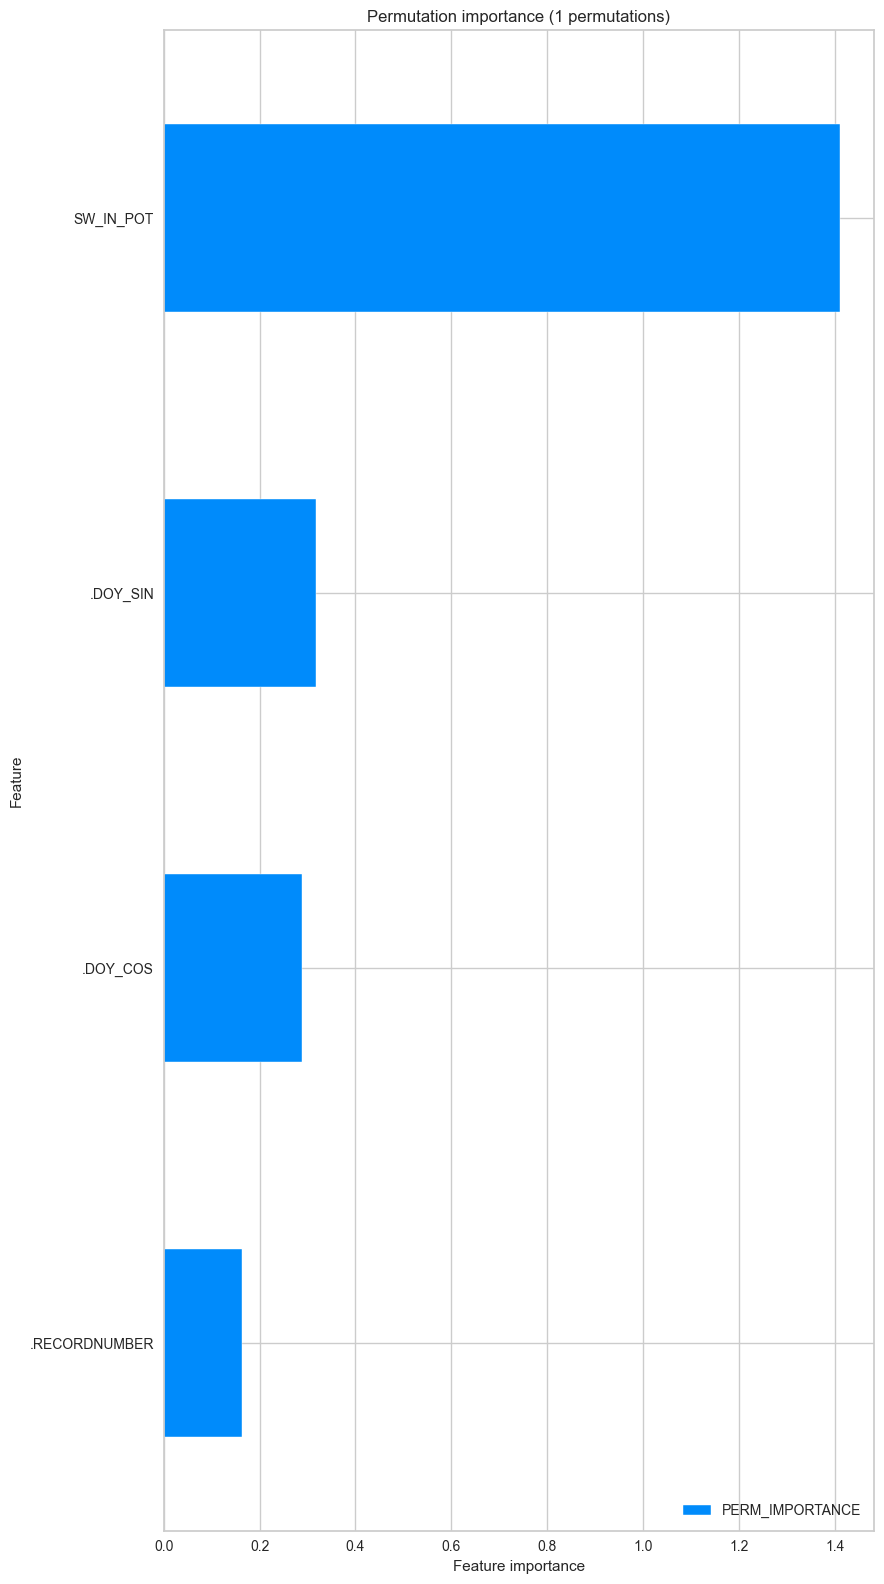

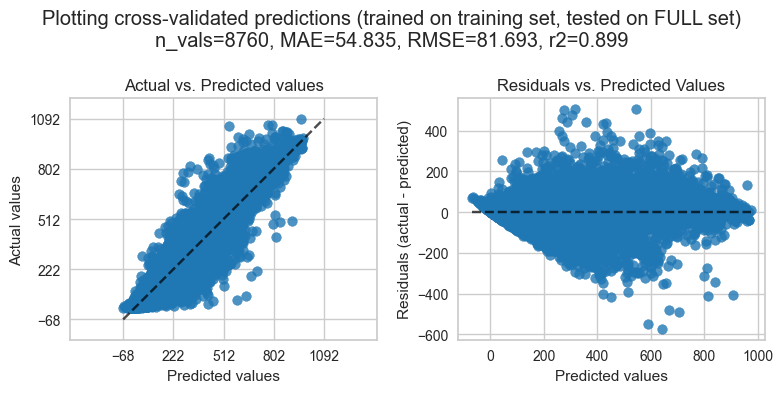

>>> Predicting target SW_IN_NABEL_T1_49_1 where all features are available ... predicted 8760 records.
>>> Collecting results for final model ...
>>> Filling 0 missing records in target with predictions from final model ...
>>> Storing gap-filled time series in variable SW_IN_NABEL_T1_49_1_gfXG ...
>>> Restoring original timestamp in results ...

Gap-filling 0 remaining missing records in SW_IN_NABEL_T1_49_1_gfXG using fallback model ...
>>> Fallback model not necessary, all gaps were already filled.
>>> Combining predictions from full model and fallback model ...

GAP-FILLING RESULTS

Model scores and feature importances were calculated from high-quality predicted targets (0 values, SW_IN_NABEL_T1_49_1_gfXG where flag=1) in comparison to observed targets (8760 values, SW_IN_NABEL_T1_49_1).

## TARGET
- first timestamp:  2006-01-01 08:45:00
- last timestamp:  2006-12-31 16:15:00
- potential number of values: 8760 values)
- target column (observed):  SW_IN_NABEL_T1_49_1
- missing record

In [23]:
xgbts.fillgaps(showplot_scores=True, showplot_importance=True)
xgbts.report_gapfilling()

## Results: yearly scores

In [24]:
xgbts.scores_

{'mae': 54.835443816698174,
 'medae': np.float64(34.54234823847381),
 'mse': 6673.695882642365,
 'rmse': 81.69269173336355,
 'mape': 0.8179863276218317,
 'maxe': np.float64(572.587239594184),
 'r2': 0.8985210508893947}

## Results: feature importances

In [25]:
xgbts.feature_importances_

,PERM_IMPORTANCE,PERM_SD
SW_IN_POT,1.411649,0.0
.DOY_SIN,0.317527,0.0
.DOY_COS,0.287433,0.0
.RECORDNUMBER,0.162956,0.0


## Results: plot gap-filled time series

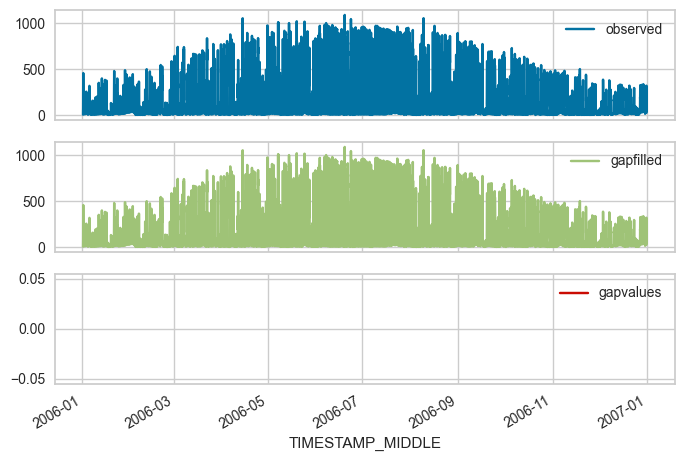

In [26]:
observed = subset[TARGET]
gapfilled = xgbts.get_gapfilled_target()
locs_filled = observed.isna()
gapvalues = gapfilled[locs_filled].copy()
# gapfilled[locs_filled].describe()
_plotdf = pd.DataFrame({
    'observed': observed,
    'gapfilled': gapfilled,
    'gapvalues': gapvalues
})
_plotdf.plot(subplots=True, x_compat=True);

## Add gap-filled series to dataframe

In [27]:
swin_2004_2025[gapfilled.name] = gapfilled
swin_2004_2025[gapfilled.name] = swin_2004_2025[gapfilled.name].fillna(swin_2004_2025[TARGET])

## Plot time series

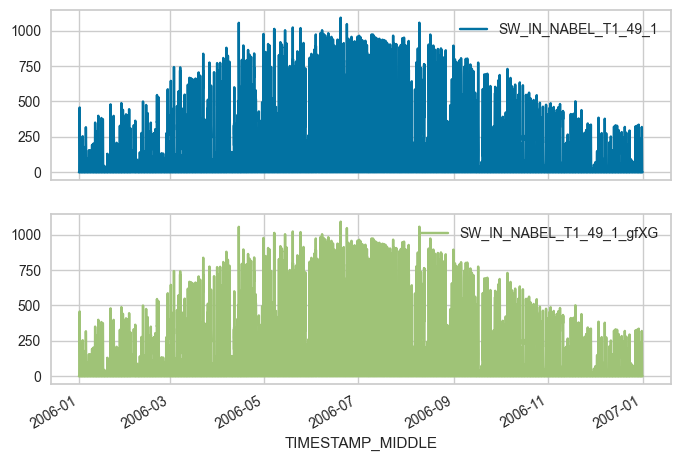

In [28]:
swin_2004_2025[[TARGET, gapfilled.name]].plot(subplots=True, x_compat=True);

## Correction: Remove zero offset
- Additional correction needed because gap-filling introduced values < 0

In [29]:
swin_2004_2025[[TARGET, gapfilled.name]].describe()

,SW_IN_NABEL_T1_49_1,SW_IN_NABEL_T1_49_1_gfXG
count,17520.000000,17520.000000
mean,134.380324,134.380324
std,225.705888,225.705888
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.065757,0.065757
75%,178.250252,178.250252
max,1092.320584,1092.320584


In [30]:
# _swin = swin_2004_2025[gapfilled.name].copy()
# _swin_corrected = remove_radiation_zero_offset(series=_swin, lat=SITE_LAT, lon=SITE_LON, utc_offset=1, showplot=True)
# swin_2004_2025[gapfilled.name] = np.nan
# swin_2004_2025[gapfilled.name] = _swin_corrected

</br>

## Dataframe

In [31]:
swin_2004_2025

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1_gfXG
TIMESTAMP_MIDDLE,,,
2006-01-01 00:15:00,0.0,0.0,0.0
2006-01-01 00:45:00,0.0,0.0,0.0
2006-01-01 01:15:00,0.0,0.0,0.0
2006-01-01 01:45:00,0.0,0.0,0.0
2006-01-01 02:15:00,0.0,0.0,0.0
...,...,...,...
2006-12-31 21:45:00,0.0,0.0,0.0
2006-12-31 22:15:00,0.0,0.0,0.0
2006-12-31 22:45:00,0.0,0.0,0.0


</br>

</br>

</br>

# 🟥 Gap-filling ETH (2004-2018) using NABEL+
- NABEL is now complete (no gaps) 2004-2018 and can be used as feature in those years

## Target and features

In [32]:
TARGET = "SW_IN_T1_47_1"
subset = pd.DataFrame()
subset = swin_2004_2025[[TARGET, 'SW_IN_NABEL_T1_49_1_gfXG']].copy()
subset = subset.loc[subset.index.year <= 2018].copy()
subset['SW_IN_POT'] = potrad(timestamp_index=subset.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
subset

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1_gfXG,SW_IN_POT
TIMESTAMP_MIDDLE,,,
2006-01-01 00:15:00,0.0,0.0,0.0
2006-01-01 00:45:00,0.0,0.0,0.0
2006-01-01 01:15:00,0.0,0.0,0.0
2006-01-01 01:45:00,0.0,0.0,0.0
2006-01-01 02:15:00,0.0,0.0,0.0
...,...,...,...
2006-12-31 21:45:00,0.0,0.0,0.0
2006-12-31 22:15:00,0.0,0.0,0.0
2006-12-31 22:45:00,0.0,0.0,0.0


In [33]:
subset = subset.loc[subset['SW_IN_POT'] > 0, :].copy()
subset

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1_gfXG,SW_IN_POT
TIMESTAMP_MIDDLE,,,
2006-01-01 08:45:00,1.670660,3.891345,87.881303
2006-01-01 09:15:00,15.035839,21.516078,174.686134
2006-01-01 09:45:00,38.593985,37.416678,251.779510
2006-01-01 10:15:00,75.338366,82.053278,317.842341
2006-01-01 10:45:00,259.641383,339.336211,371.744274
...,...,...,...
2006-12-31 14:15:00,188.149640,183.630393,358.576027
2006-12-31 14:45:00,160.747479,149.090726,301.817806
2006-12-31 15:15:00,148.375501,132.652093,233.149089


## Initialize gap-filling

In [34]:
xgbts = XGBoostTS(
    input_df=subset,
    target_col=TARGET,
    verbose=1,
    features_lag=None,
    features_lag_exclude_cols=None,
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=False,
    perm_n_repeats=1,
    n_estimators=3000,    
    random_state=42,
    # booster='gbtree',  # gbtree (default), gblinear, dart
    # device='cpu',
    # validate_parameters=True,
    # disable_default_eval_metric=False,
    early_stopping_rounds=100,
    # learning_rate=0.1,
    # max_depth=9,
    # max_delta_step=0,
    # subsample=1,
    # min_split_loss=0,
    # min_child_weight=1,
    # colsample_bytree=1,
    # colsample_bylevel=1,
    # colsample_bynode=1,
    # reg_lambda=1,
    # reg_alpha=0,
    # tree_method='auto',  # auto, hist, approx, exact
    # scale_pos_weight=1,
    # grow_policy='depthwise',  # depthwise, lossguide
    # max_leaves=0,
    # max_bin=256,
    # num_parallel_tree=1,
    n_jobs=-1
)



Starting gap-filling for
SW_IN_T1_47_1
using <class 'xgboost.sklearn.XGBRegressor'>

Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 8760.


## Reduce features across years

In [35]:
xgbts.reduce_features()
xgbts.report_feature_reduction()


[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[0]	validation_0-rmse:181.50689	validation_1-rmse:181.50689
[1]	validation_0-rmse:129.96659	validation_1-rmse:129.96659
[2]	validation_0-rmse:94.60045	validation_1-rmse:94.60045
[3]	validation_0-rmse:70.75087	validation_1-rmse:70.75087
[4]	validation_0-rmse:54.95079	validation_1-rmse:54.95079
[5]	validation_0-rmse:45.03804	validation_1-rmse:45.03804
[6]	validation_0-rmse:38.78245	validation_1-rmse:38.78245
[7]	validation_0-rmse:35.07976	validation_1-rmse:35.07976
[8]	validation_0-rmse:32.70973	validation_1-rmse:32.70973
[9]	validation_0-rmse:31.38252	validation_1-rmse:31.38252
[10]	validation_0-rmse:30.33855	validation_1-rmse:30.33855
[11]	validation_0-rmse:29.64461	validation_1-rmse:29.64461
[12]	validation_0-rmse:29.09419	validation_1-rmse:29.09419
[13]	validation_0-rmse:28.62230	validation_1-rmse:28.62230
[14]	validation_0-rmse:28.34577	validation_1-rmse:28.34577
[15]	validation_0-rmse:27.78094	validation_1

## Train model


Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2006-01-01 09:15:00 and 2006-12-31 16:15:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:181.51772	validation_1-rmse:180.23813
[1]	validation_0-rmse:130.02466	validation_1-rmse:129.13729
[2]	validation_0-rmse:94.74539	validation_1-rmse:94.49338
[3]	validation_0-rmse:70.96760	validation_1-rmse:71.45916
[4]	validation_0-rmse:55.42846	validation_1-rmse:56.82212
[5]	validation_0-rmse:45.42804	validation_1-rmse:48.05607
[6]	validation_0-rmse:39.12897	validation_1-rmse:43.24382
[7]	validation_0-rmse:35.40654	validation_1-rmse:40.44082
[8]	validation_0-rmse:33.25941	validation_1-rmse:38.94655
[9]	validation_0-rmse:31.80801	validation_1-rmse:38.17575
[10]	validation_0-rmse:30.86231	validation_1-rmse:37.86914
[11]	validation_0-rmse:30.26332	validation_1-rmse:37.68468
[12]	validation_0-rmse:29.56854	validation_1-rmse:37.63768
[13]	validation_0-rmse:29.19700	validation_1-r

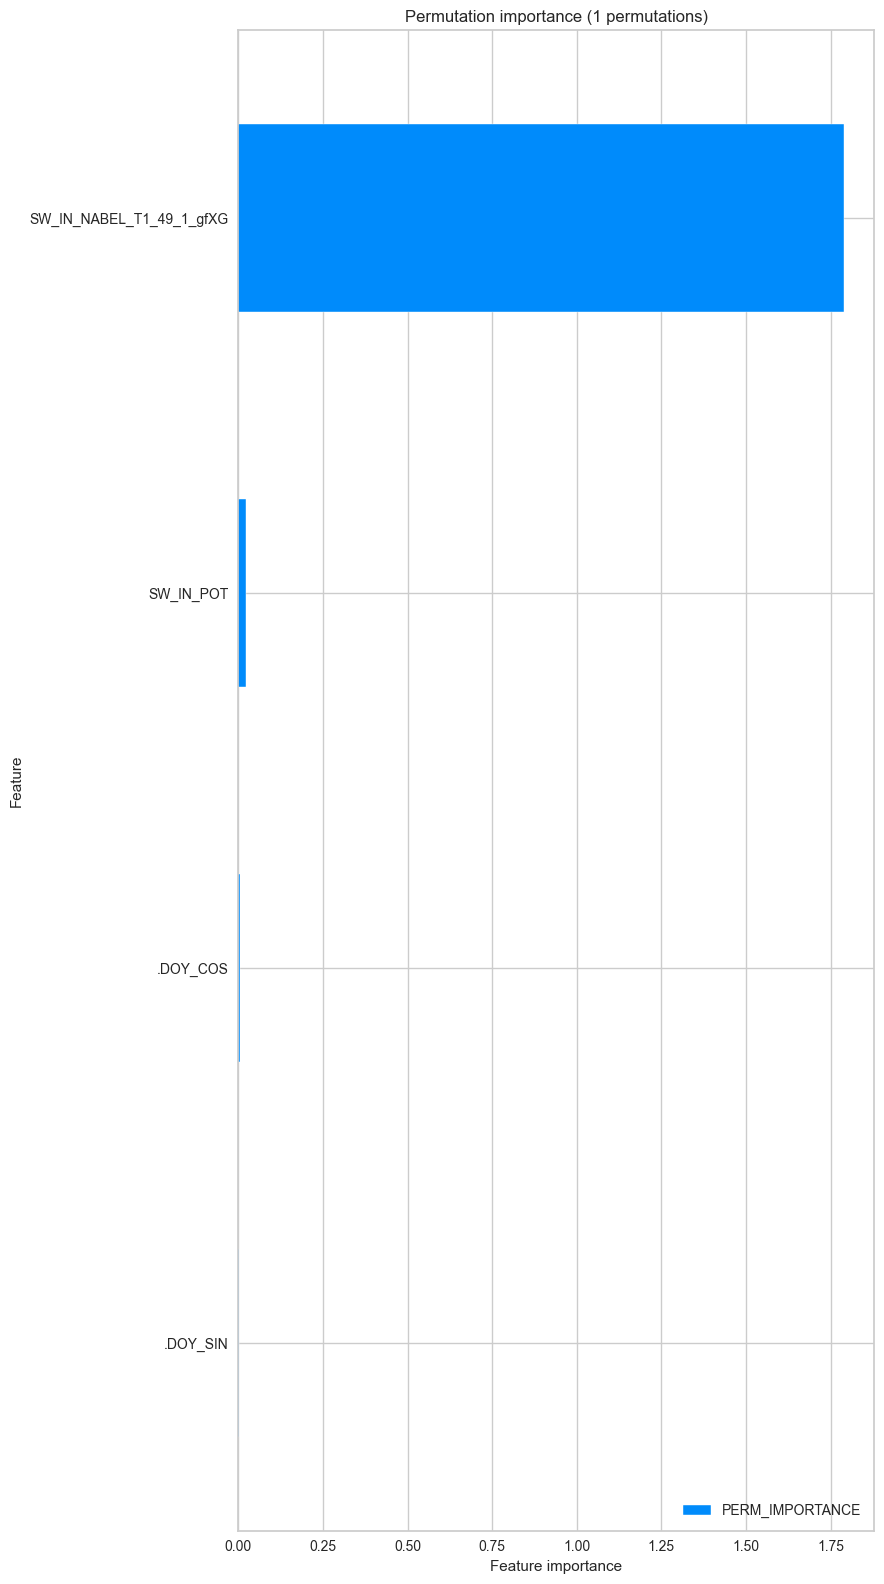

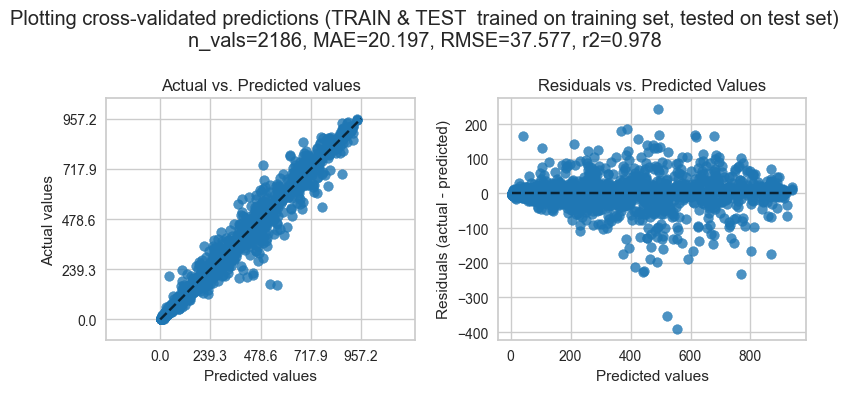

>>> Plotting residuals and prediction error ...


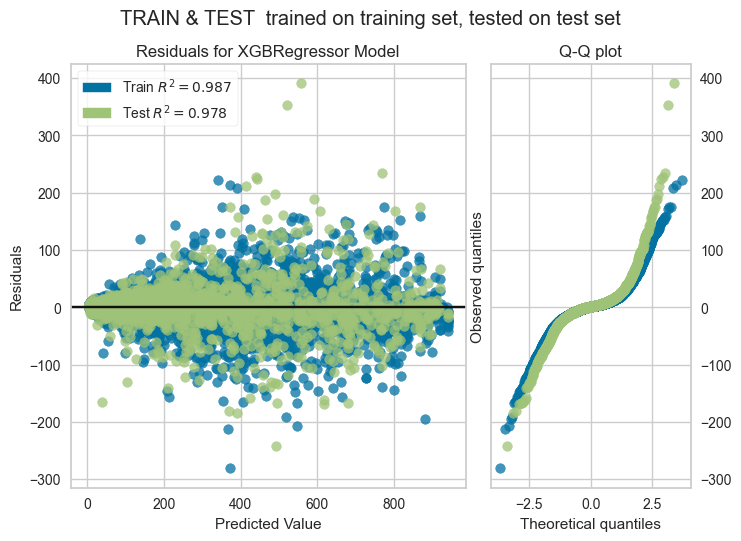

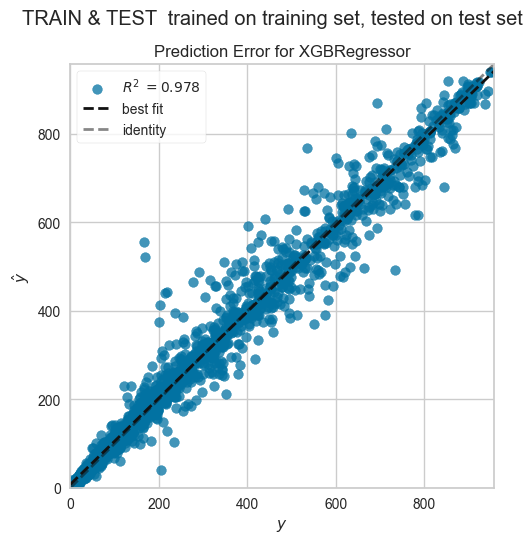

>>> Collecting results, details about training and testing can be accessed by calling .report_traintest().
>>> Done.

MODEL TRAINING & TESTING RESULTS

## DATA
  > target: SW_IN_T1_47_1
  > features: 4 ['SW_IN_NABEL_T1_49_1_gfXG', 'SW_IN_POT', '.DOY_SIN', '.DOY_COS']
  > 8760 records (with missing)
  > 8744 available records for target and all features (no missing values)
  > training on 6558 records (75.0%) of 6558 features between 2006-01-01 09:15:00 and 2006-12-31 16:15:00
  > testing on 2186 unseen records (25.0%) of SW_IN_T1_47_1 between 2006-01-01 08:45:00 and 2006-12-31 15:45:00

## MODEL
  > the model was trained on training data (6558 records)
  > the model was tested on test data (2186 values)
  > estimator:  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=100,
             enable_categorical=False, eval_metric=None, feature_types=None

In [36]:
xgbts.trainmodel(showplot_scores=True, showplot_importance=True)
xgbts.report_traintest()

## Fill gaps


Gap-filling using final model ...
>>> Using final model on all data to predict target SW_IN_T1_47_1 ...
>>> Using final model on all data to calculate permutation importance ...
>>> Plotting feature importances (permutation importance) ...
>>> Calculating prediction scores based on all data predicting SW_IN_T1_47_1 ...
>>> Plotting observed and predicted values based on all data ...


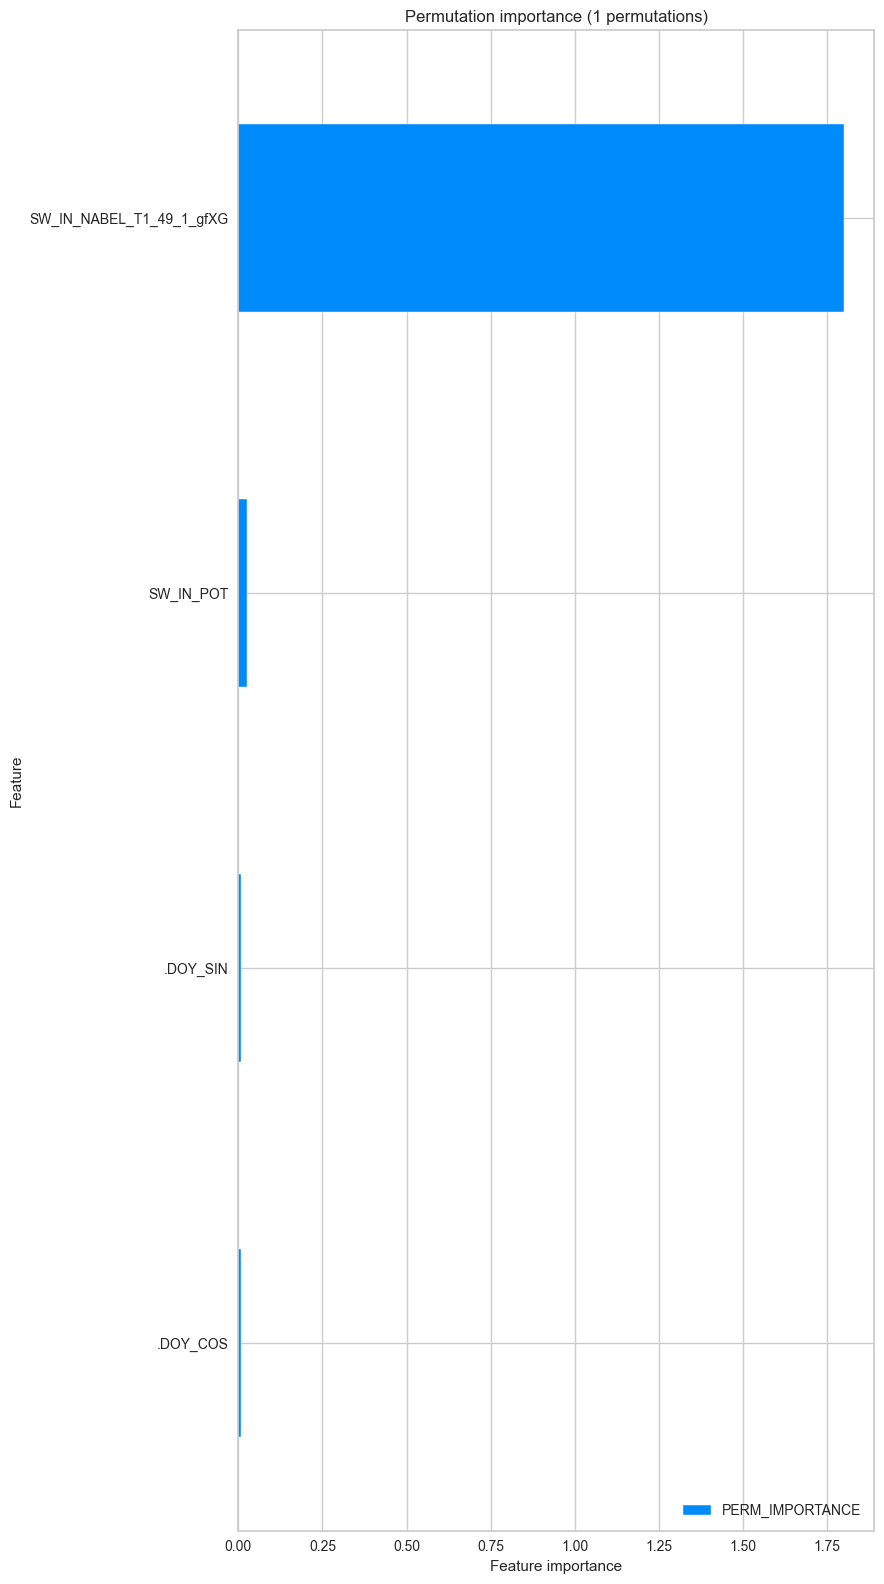

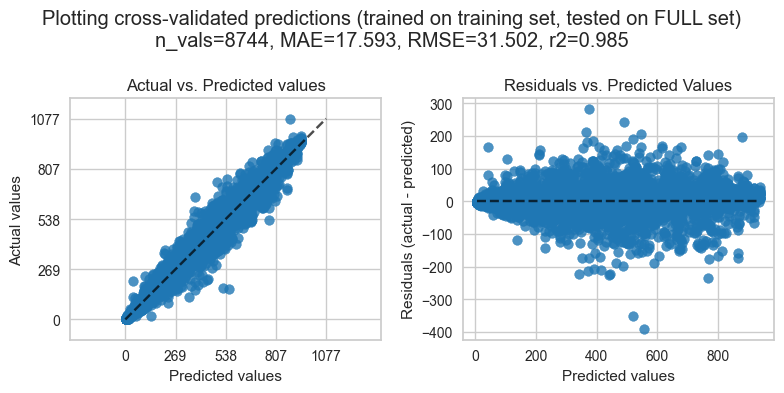

>>> Predicting target SW_IN_T1_47_1 where all features are available ... predicted 8760 records.
>>> Collecting results for final model ...
>>> Filling 16 missing records in target with predictions from final model ...
>>> Storing gap-filled time series in variable SW_IN_T1_47_1_gfXG ...
>>> Restoring original timestamp in results ...

Gap-filling 0 remaining missing records in SW_IN_T1_47_1_gfXG using fallback model ...
>>> Fallback model not necessary, all gaps were already filled.
>>> Combining predictions from full model and fallback model ...

GAP-FILLING RESULTS

Model scores and feature importances were calculated from high-quality predicted targets (16 values, SW_IN_T1_47_1_gfXG where flag=1) in comparison to observed targets (8744 values, SW_IN_T1_47_1).

## TARGET
- first timestamp:  2006-01-01 08:45:00
- last timestamp:  2006-12-31 16:15:00
- potential number of values: 8760 values)
- target column (observed):  SW_IN_T1_47_1
- missing records (observed):  16 (cross-check fro

In [37]:
xgbts.fillgaps(showplot_scores=True, showplot_importance=True)
xgbts.report_gapfilling()

## Results: yearly scores

In [38]:
xgbts.scores_

{'mae': 17.593019234446626,
 'medae': np.float64(8.494207030152282),
 'mse': 992.351167274797,
 'rmse': 31.501605788829195,
 'mape': 64928623367324.7,
 'maxe': np.float64(390.5829157524488),
 'r2': 0.9848068813076937}

## Results: feature importances

In [39]:
xgbts.feature_importances_

,PERM_IMPORTANCE,PERM_SD
SW_IN_NABEL_T1_49_1_gfXG,1.800254,0.0
SW_IN_POT,0.024829,0.0
.DOY_SIN,0.006951,0.0
.DOY_COS,0.006333,0.0


## Results: plot gap-filled time series

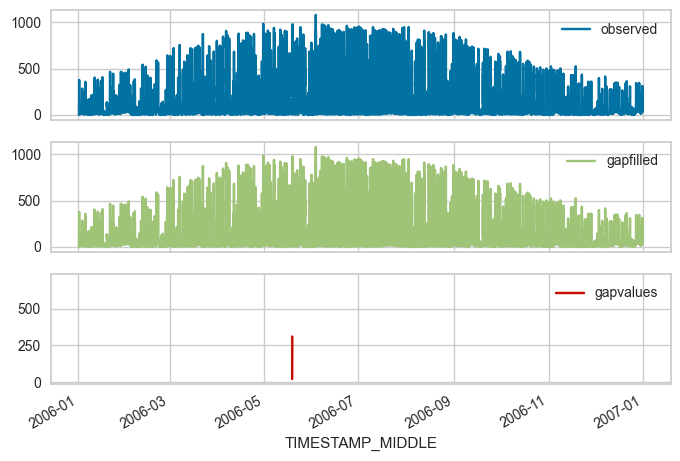

In [40]:
observed = subset[TARGET]
gapfilled = xgbts.get_gapfilled_target()
locs_filled = observed.isna()
gapvalues = gapfilled[locs_filled].copy()
# gapfilled[locs_filled].describe()
_plotdf = pd.DataFrame({
    'observed': observed,
    'gapfilled': gapfilled,
    'gapvalues': gapvalues
})
_plotdf.plot(subplots=True, x_compat=True);

## Add gap-filled series to dataframe

In [41]:
swin_2004_2025[gapfilled.name] = gapfilled
swin_2004_2025[gapfilled.name] = swin_2004_2025[gapfilled.name].fillna(swin_2004_2025[TARGET])

## Plot time series

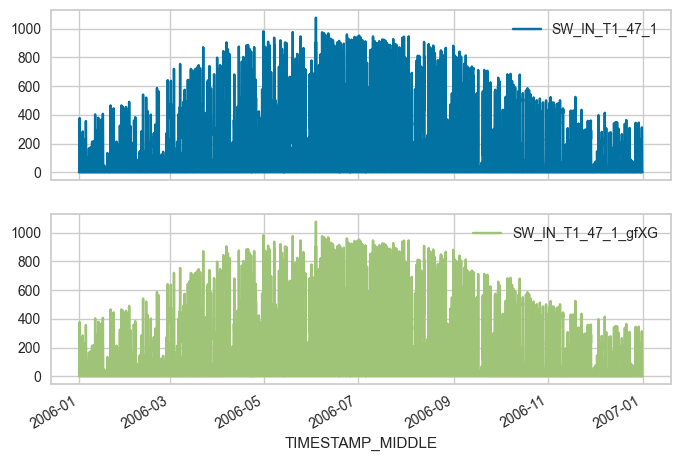

In [42]:
swin_2004_2025[[TARGET, gapfilled.name]].plot(subplots=True, x_compat=True);

## Correction: Remove zero offset
- Additional correction needed because gap-filling introduced values < 0

In [43]:
swin_2004_2025[[TARGET, gapfilled.name]].describe()

,SW_IN_T1_47_1,SW_IN_T1_47_1_gfXG
count,17504.000000,17520.000000
mean,136.033024,136.212619
std,226.207496,226.302624
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,183.547221,184.106871
max,1076.567623,1076.567623


In [44]:
# _swin = swin_2004_2025[gapfilled.name].copy()
# _swin_corrected = remove_radiation_zero_offset(series=_swin, lat=SITE_LAT, lon=SITE_LON, utc_offset=1, showplot=True)
# swin_2004_2025[gapfilled.name] = np.nan
# swin_2004_2025[gapfilled.name] = _swin_corrected

</br>

## Dataframe

In [45]:
swin_2004_2025

,SW_IN_NABEL_T1_49_1,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1_gfXG,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,,
2006-01-01 00:15:00,0.0,0.0,0.0,0.0
2006-01-01 00:45:00,0.0,0.0,0.0,0.0
2006-01-01 01:15:00,0.0,0.0,0.0,0.0
2006-01-01 01:45:00,0.0,0.0,0.0,0.0
2006-01-01 02:15:00,0.0,0.0,0.0,0.0
...,...,...,...,...
2006-12-31 21:45:00,0.0,0.0,0.0,0.0
2006-12-31 22:15:00,0.0,0.0,0.0,0.0
2006-12-31 22:45:00,0.0,0.0,0.0,0.0


</br>

# Heatmap

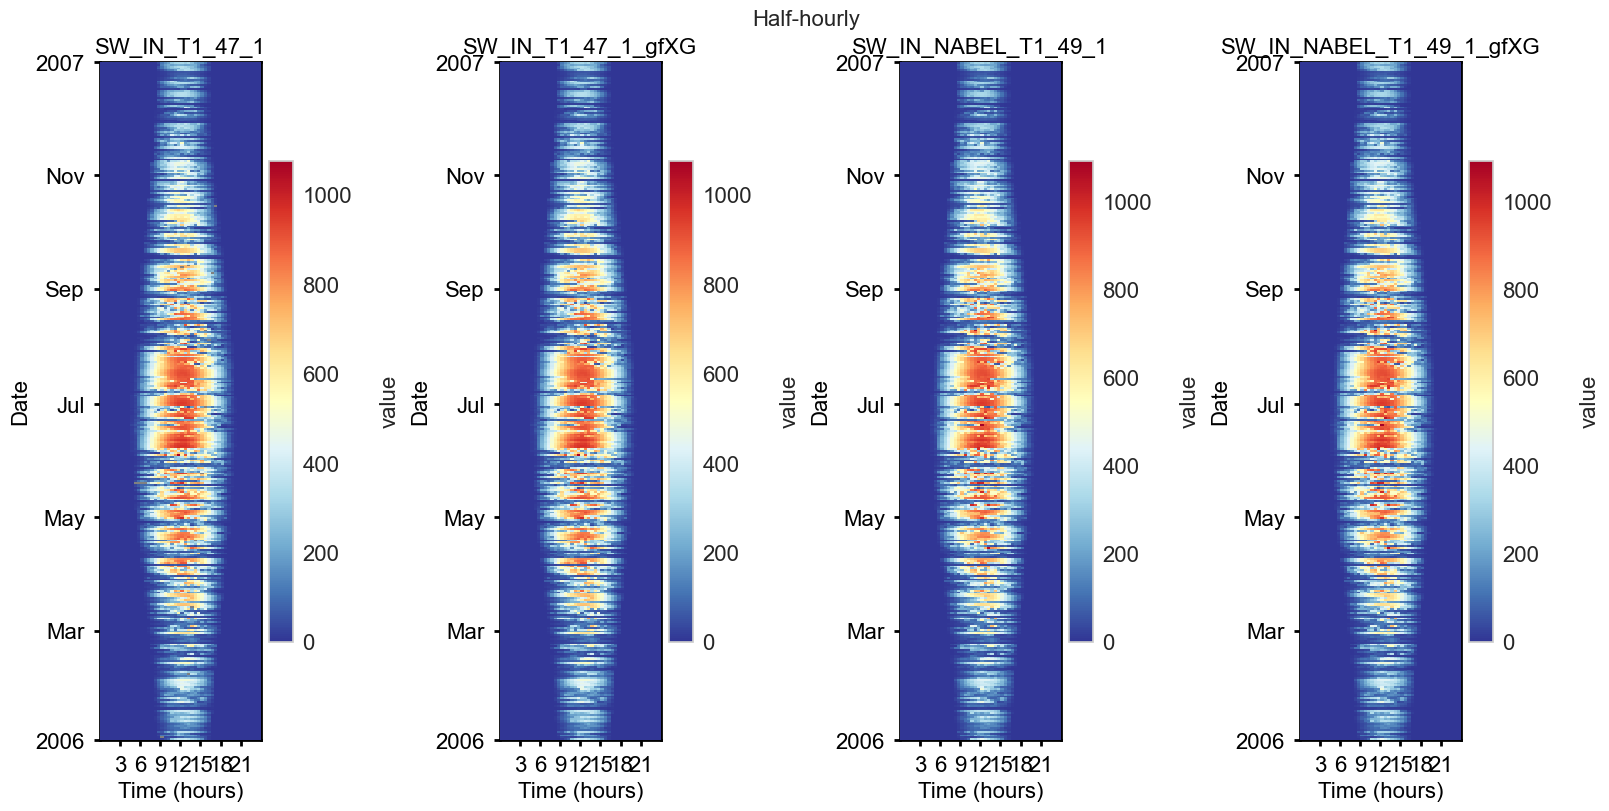

In [48]:
fig, axs = plt.subplots(ncols=4, figsize=(16, 8), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.heatmapdatetime(series=swin_2004_2025['SW_IN_T1_47_1'], title="SW_IN_T1_47_1", ax=axs[0], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=swin_2004_2025['SW_IN_T1_47_1_gfXG'], title="SW_IN_T1_47_1_gfXG", ax=axs[1], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=swin_2004_2025['SW_IN_NABEL_T1_49_1'], title="SW_IN_NABEL_T1_49_1", ax=axs[2], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=swin_2004_2025['SW_IN_NABEL_T1_49_1_gfXG'], title="SW_IN_NABEL_T1_49_1_gfXG", ax=axs[3], cb_digits_after_comma=0, zlabel="value").plot()

</br>

</br>

# Save to file

In [ ]:
OUTNAME = "02_METEO_SW_IN_GAPFILLED_2004-2025"
OUTPATH = r""
filepath = save_parquet(filename=OUTNAME, data=merged_df, outpath=OUTPATH)
merged_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")

</br>

# End of notebook.

In [ ]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

</br>